In [ ]:
# @title 🚀 Setup (Run this cell first!)
import os
import sys

# 1. Detect if we are in Google Colab
if 'google.colab' in sys.modules:
    print("Running in Google Colab. Setting up environment...")
    
    # 2. Define the source of your data files 
    BASE_URL = "https://raw.githubusercontent.com/fhfarnoud/intro2ml/main/2026S/data/"
    
    # 3. List the files you need
    files_to_download = ['canterville_ghost.txt']
    
    # 4. Download the files
    if not os.path.exists('data'):
        os.makedirs('data')
        
    for filename in files_to_download:
        if not os.path.exists(f"data/{filename}"):
            url = f"{BASE_URL}{filename}"
            print(f"Downloading {filename}...")
            !wget -q -O data/{filename} {url}
            
    print("✅ Setup complete! Data files are ready.")
else:
    print("Running locally. Assuming data is already present.")


# Lecture 17: Probability & Predicting the Unknown

In this notebook, we explore probability through simulation and data. The key question throughout: **how do we figure out what's likely to happen next?**

In [2]:
import random
import matplotlib.pyplot as plt
from collections import Counter

## 1. Simulating Randomness: Rolling Dice

Let's start with the simplest random experiment: rolling dice. We'll use simulation to build intuition about probability.

In [3]:
# Roll a single die N times and display the results
N = 30
rolls = []
for i in range(N):
    r = random.randint(1, 6)
    rolls.append(r)
print("Rolls:", rolls)

Rolls: [2, 5, 4, 2, 4, 4, 4, 4, 5, 5, 4, 4, 2, 2, 1, 3, 3, 1, 4, 6, 4, 5, 3, 2, 2, 4, 3, 4, 3, 3]


### Distribution of a single die

If the die is fair, each face should appear roughly $1/6 \approx 16.7\%$ of the time. Let's check.

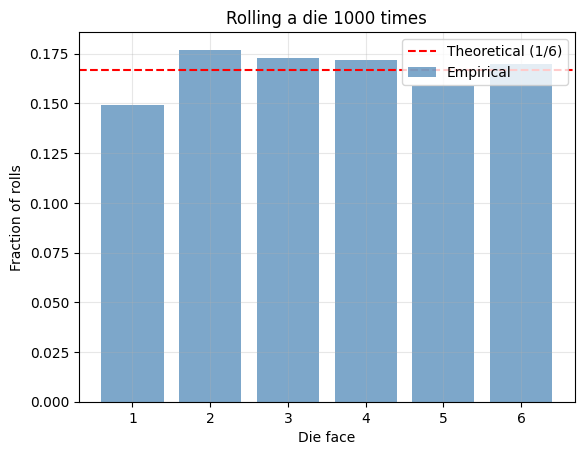

In [4]:
# Count how many times each face appears
N = 1000
rolls = []
for i in range(N):
    rolls.append(random.randint(1, 6))

# Count occurrences of each face
counts = [0, 0, 0, 0, 0, 0]
for r in rolls:
### BEGIN SOLUTION
    counts[r - 1] = counts[r - 1] + 1
### END SOLUTION

# Convert to fractions
fractions = []
for c in counts:
    fractions.append(c / N)

# Plot
faces = [1, 2, 3, 4, 5, 6]
plt.bar(faces, fractions, color='steelblue', alpha=0.7, label='Empirical')
plt.axhline(y=1/6, color='red', linestyle='--', label='Theoretical (1/6)')
plt.xlabel('Die face')
plt.ylabel('Fraction of rolls')
plt.title(f'Rolling a die {N} times')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 2. Distribution of the Sum of Two Dice

When we roll two dice and add them, some sums are more likely than others. There are 6 ways to get a sum of 7, but only 1 way to get a sum of 2.

Let's simulate this and compare to the theoretical distribution.

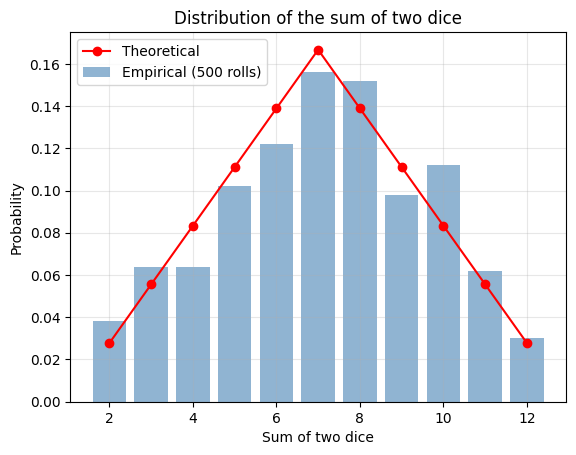

In [5]:
# Simulate rolling two dice N times
N = 500
sums = []
for i in range(N):
### BEGIN SOLUTION
    die1 = random.randint(1, 6)
    die2 = random.randint(1, 6)
    sums.append(die1 + die2)
### END SOLUTION

# Count how often each sum appears
sum_values = list(range(2, 13))  # possible sums: 2 through 12
empirical_counts = [0] * 11
for s in sums:
    empirical_counts[s - 2] = empirical_counts[s - 2] + 1

empirical_fractions = []
for c in empirical_counts:
    empirical_fractions.append(c / N)

# Theoretical probabilities (from counting the 6x6 table)
### BEGIN SOLUTION
theoretical = [1/36, 2/36, 3/36, 4/36, 5/36, 6/36, 5/36, 4/36, 3/36, 2/36, 1/36]
### END SOLUTION

# Plot both
plt.bar(sum_values, empirical_fractions, alpha=0.6, color='steelblue', label=f'Empirical ({N} rolls)')
plt.plot(sum_values, theoretical, 'ro-', label='Theoretical')
plt.xlabel('Sum of two dice')
plt.ylabel('Probability')
plt.title('Distribution of the sum of two dice')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**TODO:** Try changing `N` in the cell above from 500 to 50, then to 5000. What happens to the histogram?

**Answer:** With N=50, the histogram is noisy and jagged — some sums appear much more or less often than expected. With N=5000, the histogram closely matches the theoretical triangle shape. This illustrates the **law of large numbers**: the more data we collect, the closer the empirical distribution gets to the true distribution.

## 3. Word Frequencies in Real Text

In English text, some words appear far more often than others. Let's count word frequencies in a paragraph from Oscar Wilde's *The Canterville Ghost*.

### NEW: `Counter()`

Counts how often each item appears in a list (or any sequence):

```python
from collections import Counter

words = ["the", "cat", "the", "hat"]
word_counts = Counter(words)
# Counter({'the': 2, 'cat': 1, 'hat': 1})

word_counts.most_common(2)   # [('the', 2), ('cat', 1)] — top 2 most frequent
```

In [6]:
# Opening paragraph from The Canterville Ghost by Oscar Wilde
short_text = """When Mr Hiram B Otis the American Minister bought Canterville Chase
every one told him he was doing a very foolish thing as there was no doubt at
all that the place was haunted Indeed Lord Canterville himself who was a man of
the most punctilious honour had felt it his duty to mention the fact to Mr Otis
when they came to discuss terms We have not cared to live in the place ourselves
said Lord Canterville since my grand aunt the Dowager Duchess of Bolton was
frightened into a fit from which she never really recovered"""

# Convert to lowercase and split into words
short_words = short_text.lower().split()

# Count word frequencies
### BEGIN SOLUTION
short_counts = Counter(short_words)
### END SOLUTION

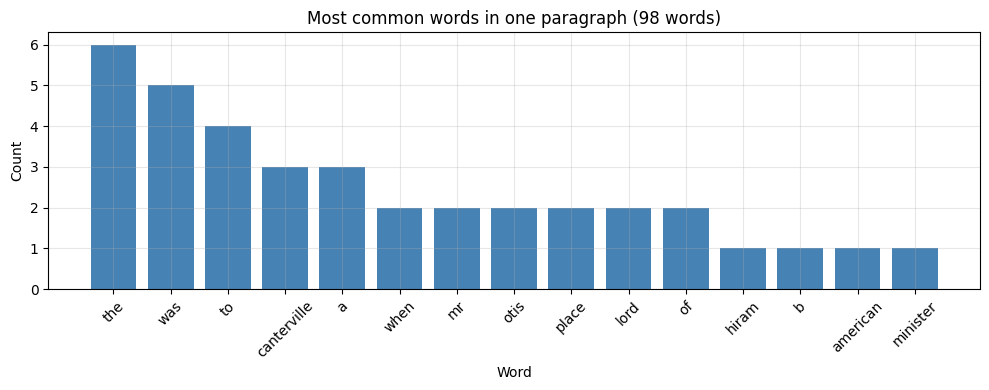

In [7]:
# Plot the top 15 words
top_words_short = short_counts.most_common(15)
labels = []
counts = []
for word, count in top_words_short:
    labels.append(word)
    counts.append(count)

plt.figure(figsize=(10, 4))
plt.bar(labels, counts, color='steelblue')
plt.xlabel('Word')
plt.ylabel('Count')
plt.title(f'Most common words in one paragraph ({len(short_words)} words)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

With one paragraph, the top words are noisy and story-specific ("canterville", "otis"). With the whole book, the distribution stabilizes: common English words ("the", "and", "of") dominate, and the gap between top words and rare words grows. This pattern --- a few items are very common, most are rare --- is called a **power law** and appears everywhere: word frequencies, city populations, website traffic.

### More data = better estimate

Does the distribution change with more text? Let's compare three samples from the same story: one paragraph, three paragraphs, and the whole book.

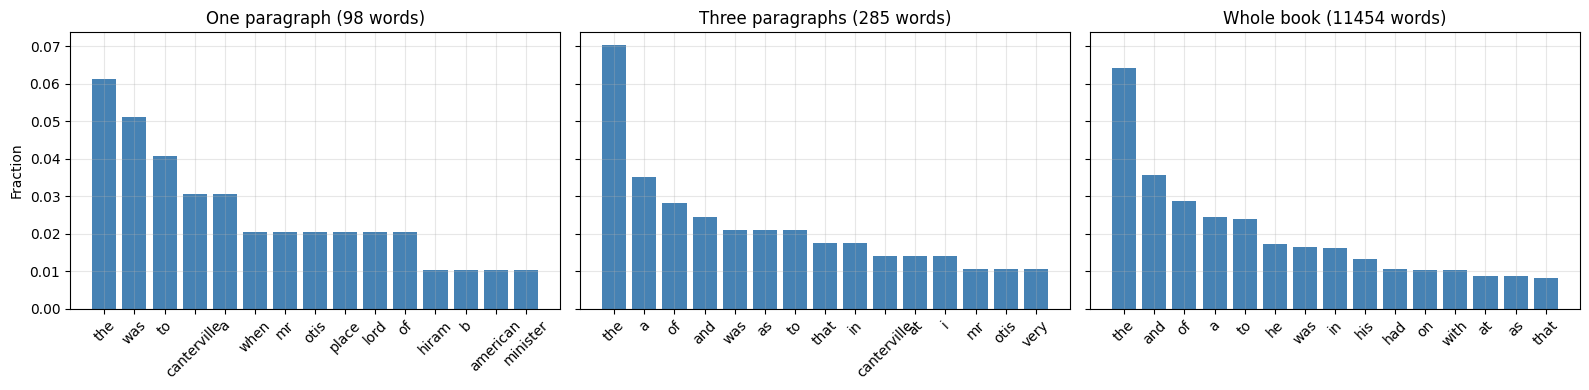

In [8]:
# --- Three paragraphs ---
long_text = """When Mr Hiram B Otis the American Minister bought Canterville Chase
every one told him he was doing a very foolish thing as there was no doubt at
all that the place was haunted Indeed Lord Canterville himself who was a man of
the most punctilious honour had felt it his duty to mention the fact to Mr Otis
when they came to discuss terms We have not cared to live in the place ourselves
said Lord Canterville since my grand aunt the Dowager Duchess of Bolton was
frightened into a fit from which she never really recovered by two skeleton hands
being placed on her shoulders as she was dressing for dinner and I feel bound to
tell you Mr Otis that the ghost has been seen by several living members of my
family as well as by the rector of the parish the Rev Augustus Dampier who is a
Fellow of Kings College Cambridge After the unfortunate accident to the Duchess
none of our younger servants would stay with us and Lady Canterville often got
very little sleep at night in consequence of the mysterious noises that came from
the corridor and the library My Lord answered the Minister I will take the
furniture and the ghost at a valuation I come from a modern country where we have
everything that money can buy and with all our spry young fellows painting the
Old World red and carrying off your best actresses and prima donnas I reckon that
if there were such a thing as a ghost in Europe we would have it at home in a
very short time in one of our public museums or on the road as a show"""
long_words = long_text.lower().split()
long_counts = Counter(long_words)

# --- Whole book ---
with open("data/canterville_ghost.txt") as f:
    book_text = f.read()
book_words = book_text.lower().split()
book_counts = Counter(book_words)

# Plot all three side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

top_words_short = short_counts.most_common(15)
top_words_long = long_counts.most_common(15)
top_words_whole = book_counts.most_common(15)

datasets = [
    (top_words_short, len(short_words), "One paragraph"),
    (top_words_long, len(long_words), "Three paragraphs"),
    (top_words_whole, len(book_words), "Whole book"),
]

for ax, (top_words, n, title) in zip(axes, datasets):
    labels = []
    heights = []
    for w, c in top_words:
        labels.append(w)
        heights.append(c / n)
    ax.bar(labels, heights, color='steelblue')
    ax.set_title(f"{title} ({n} words)")
    ax.set_ylabel('Fraction' if ax == axes[0] else '')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Generating Fake Words That Sound Real

In the lecture, we saw that picking words independently doesn't produce anything that looks like a sentence. Can we do the same trick with **letters** --- pick them one at a time and produce something that looks like English?

### 4.1 Independent sampling

In [9]:
# Use the longer Wilde passage, keeping only letters and spaces
clean_text = ""
for ch in long_text.lower():
    if ch.isalpha() or ch == " ":
        clean_text = clean_text + ch

# Build the list of unique characters (including space)
letter_counts = Counter(clean_text)
total_chars = sum(letter_counts.values())
letters = list(letter_counts.keys())

# Independent distribution: probs[j] = probability of letter j overall
probs = []
for l in letters:
    probs.append(letter_counts[l] / total_chars)

print(f"{len(letters)} unique characters (including space)")
print(f"probs: list of {len(probs)} probabilities")

24 unique characters (including space)
probs: list of 24 probabilities


In [10]:
# Generate 20 fake "words" using the INDEPENDENT distribution (probs)
# Each word: sample letters from probs until we draw a space
random.seed(42)
independent_words = []
for w in range(20):
    word = ""
    while True:
        # Sample a letter using cumulative probabilities
        r = random.random()
        cumulative = 0
        for j in range(len(letters)):
            cumulative = cumulative + probs[j]
            if r < cumulative:
                ch = letters[j]
                break
        if ch == " " and len(word) > 0:
            break
        if ch != " ":
            word = word + ch
    independent_words.append(word)

print("Independent (each letter drawn from probs):")
print(independent_words)

Independent (each letter drawn from probs):
['oh', 'nttlemhnihnoanacwct', 'ed', 'eeubctaf', 'auogath', 'e', 'e', 'o', 'n', 'yoonte', 'poatus', 'h', 'ndv', 'o', 'lr', 'a', 'al', 'nkieheosmh', 'pifgwtta', 'oerrdv']


The code above samples each letter using the **cumulative probability trick**: draw a random number $r$ in [0, 1), then walk through `probs` adding them up until the running total exceeds $r$.

**TODO:** Why does this work? If a letter has probability 30%, explain why the cumulative method picks it roughly 30% of the time.

**Answer:** Each probability occupies a segment of the interval [0, 1], and the segment’s width equals the probability. For example, if the probabilities are [0.3, 0.5, 0.2], the segments are [0, 0.3), [0.3, 0.8), [0.8, 1.0). Since `r` is uniformly random in [0, 1), it lands in each segment with probability equal to that segment’s width — so a letter with probability 30% gets picked roughly 30% of the time.

### 4.2 Using conditional probabilities

The independent words don't look like English at all! That's because real English has strong patterns: "th" is common, "tx" is not.

To capture these patterns, we build a **conditional distribution**: for each letter, what is the probability of each possible *next* letter?

In [11]:
# Map each letter to its index in the list
letter_to_index = {}
for i in range(len(letters)):
    letter_to_index[letters[i]] = i

# Count how often each letter follows each other letter
pair_counts = {}
for i in range(len(clean_text) - 1):
    current = clean_text[i]
    next_char = clean_text[i + 1]
    if current not in pair_counts:
        pair_counts[current] = {}
    if next_char not in pair_counts[current]:
        pair_counts[current][next_char] = 0
    pair_counts[current][next_char] = pair_counts[current][next_char] + 1

# cond_probs[i][j] = probability of letters[j] following letters[i]
cond_probs = []
for i in range(len(letters)):
    row = [0] * len(letters)
    current = letters[i]
    if current in pair_counts:
        total = sum(pair_counts[current].values())
        for next_char in pair_counts[current]:
            j = letter_to_index[next_char]
            row[j] = pair_counts[current][next_char] / total
    cond_probs.append(row)

print(f"cond_probs: {len(cond_probs)} x {len(cond_probs[0])} table")

cond_probs: 24 x 24 table


In [12]:
# Generate 20 fake "words" using the CONDITIONAL distribution (cond_probs)
# Each word: start from space, sample next letter from cond_probs[current], stop at space
random.seed(42)
space_index = letter_to_index[" "]
conditional_words = []
for w in range(20):
    word = ""
    current_index = space_index  # start from a space
    while True:
        # Sample next letter using cumulative probabilities from cond_probs[current_index]
        r = random.random()
        cumulative = 0
        for j in range(len(letters)):
            cumulative = cumulative + cond_probs[current_index][j]
            if r < cumulative:
                ch = letters[j]
                break
        if ch == " " and len(word) > 0:
            break
        if ch != " ":
            word = word + ch
        current_index = letter_to_index[ch]
    conditional_words.append(word)

print("Conditional (each letter drawn from cond_probs[previous]):")
print(conditional_words)

Conditional (each letter drawn from cond_probs[previous]):
['the', 'sile', 'were', 't', 'righas', 'nd', 'heveus', 'pitoug', 'she', 'hen', 'te', 'm', 'fisese', 'pubtoune', 'inds', 'tey', 'inthila', 'kine', 'tainifrdowas', 'ishe']


**Compare the two word lists** (scroll up to see the independent version):
- The independent "words" are random jumbles of letters --- nothing sounds like English.
- The conditional "words" look much more plausible --- you can imagine some of them being real words.

Even conditioning on just **one previous letter** makes a dramatic difference. What if we conditioned on the previous 2 letters? Or the previous *word*? That's the idea behind modern language models --- and that's what we'll explore in the next lectures.

## Summary

1. **Probability** tells us how likely outcomes are (0 = impossible, 1 = certain)
2. **Distributions** summarize all possibilities --- estimated from data or computed from assumptions
3. **More data** gives better estimates of the true distribution
4. **Conditioning** on context dramatically improves predictions --- even one previous letter makes generated text look more English-like
5. This is the foundation of language models: chaining conditional predictions to model sequences

**Next time (L18):** We'll scale this up from letters to *words* and build a Markov text generator that produces readable sentences from classic literature.